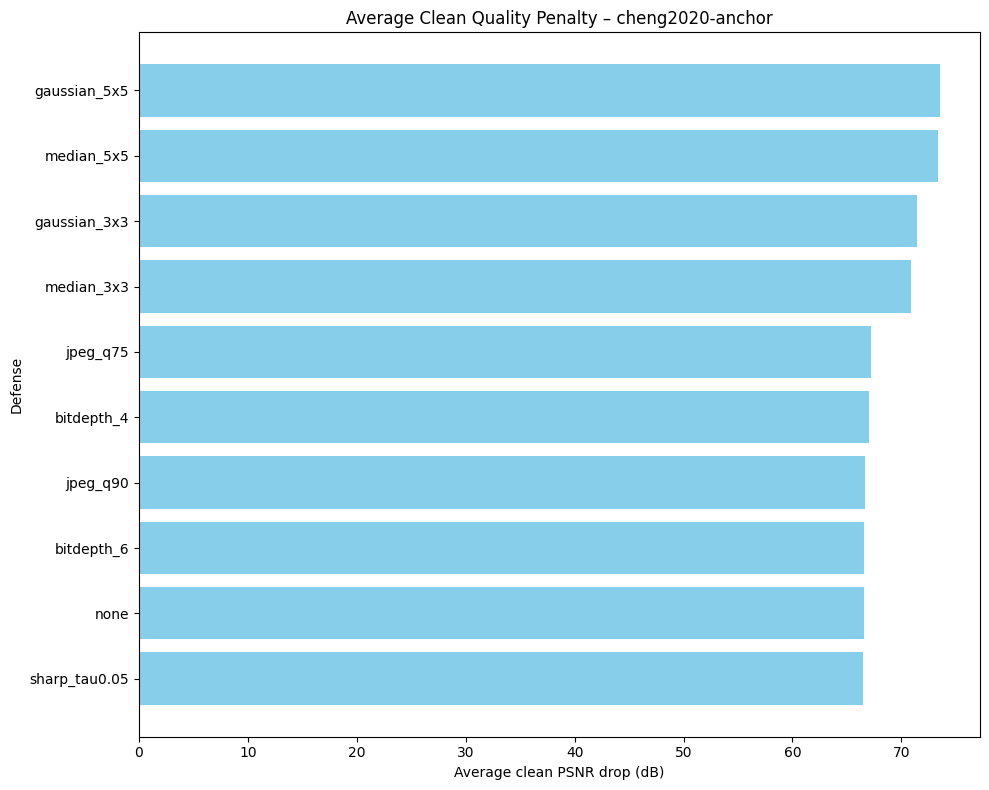

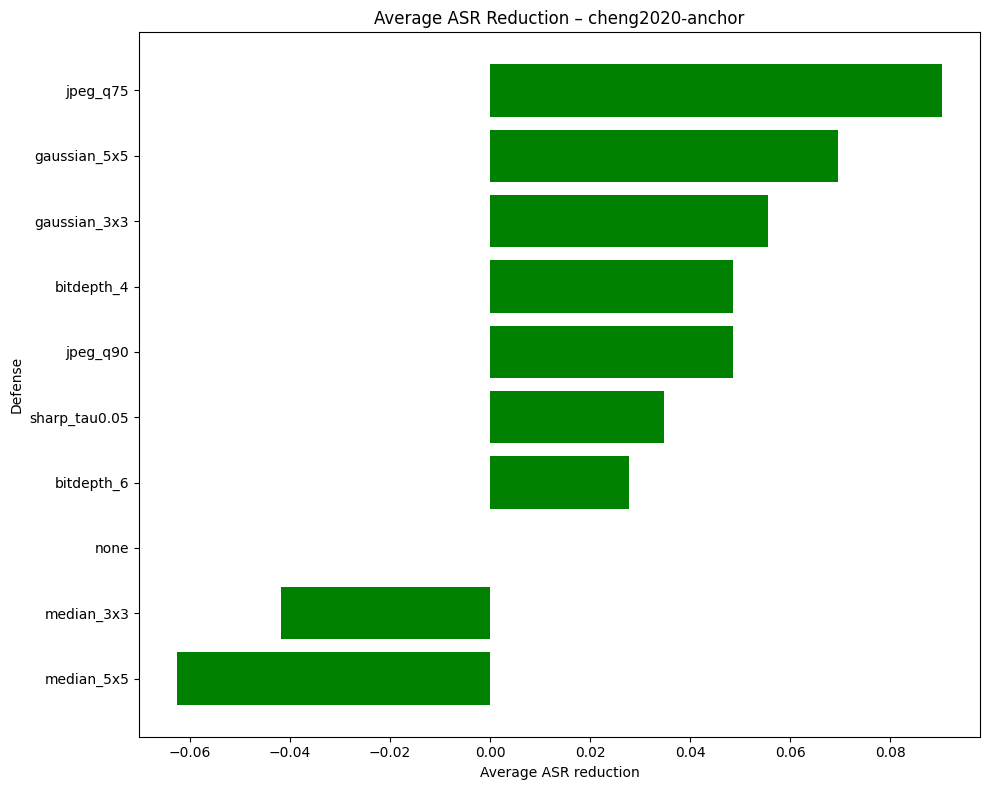

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('defense_before_attack_cheng2020-anchor.csv')
MODEL_NAME='cheng2020-anchor'

# 6.3 Average clean PSNR drop horizontal bar chart (across all attacks/eps)
avg_clean_penalty = df.groupby('defense')['clean_psnr_drop'].mean().sort_values()
plt.figure(figsize=(10, 8))
plt.barh(avg_clean_penalty.index, avg_clean_penalty.values, color='skyblue')
plt.xlabel('Average clean PSNR drop (dB)')
plt.ylabel('Defense')
plt.title(f'Average Clean Quality Penalty – {MODEL_NAME}')
plt.tight_layout()
plt.savefig(f'avg_clean_penalty_{MODEL_NAME}.png', dpi=150)
plt.show()

df_with_reduction=pd.read_csv('defense_before_attack_cheng2020-anchor_with_reduction.csv')
# 6.4 Average ASR reduction horizontal bar chart (across all attacks/eps)
avg_asr_reduction = df_with_reduction.groupby('defense')['asr_reduction'].mean().sort_values()
plt.figure(figsize=(10, 8))
plt.barh(avg_asr_reduction.index, avg_asr_reduction.values, color='green')
plt.xlabel('Average ASR reduction')
plt.ylabel('Defense')
plt.title(f'Average ASR Reduction – {MODEL_NAME}')
plt.tight_layout()
plt.savefig(f'avg_asr_reduction_{MODEL_NAME}.png', dpi=150)
plt.show()

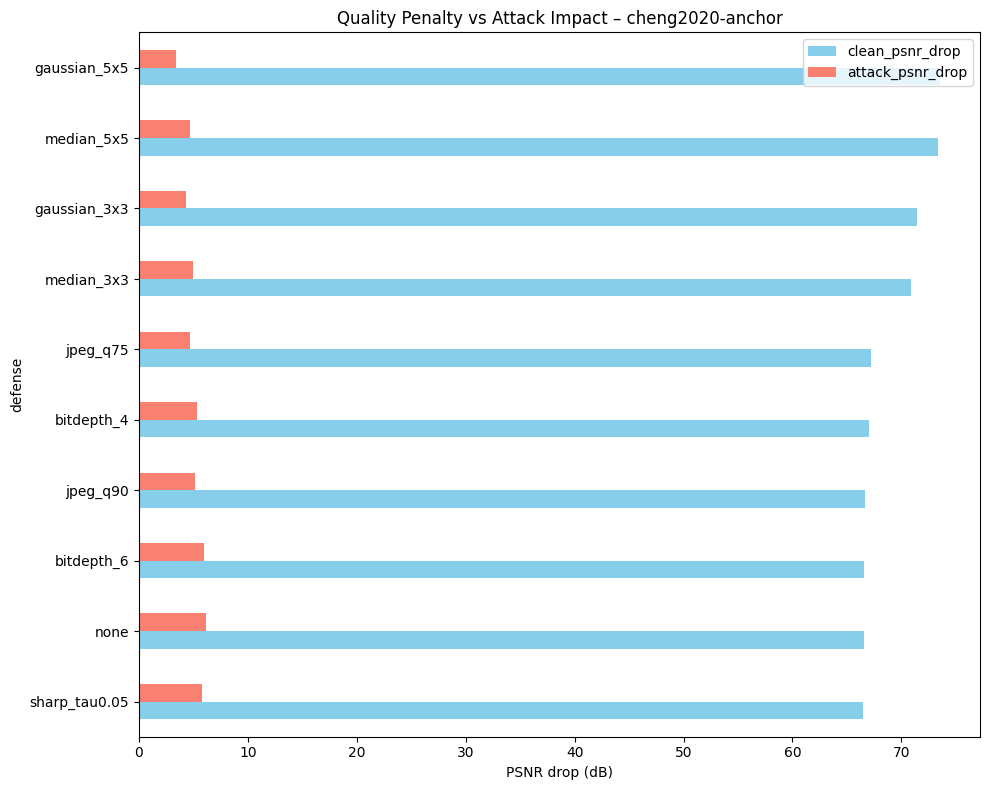

In [9]:
# Prepare data
metrics = df.groupby('defense')[['clean_psnr_drop', 'attack_psnr_drop']].mean().sort_values('clean_psnr_drop')

fig, ax = plt.subplots(figsize=(10, 8))
metrics.plot(kind='barh', ax=ax, color=['skyblue', 'salmon'])
ax.set_xlabel('PSNR drop (dB)')
ax.set_title(f'Quality Penalty vs Attack Impact – {MODEL_NAME}')
plt.tight_layout()
plt.savefig(f'combined_penalty_{MODEL_NAME}.png', dpi=150)
plt.show()

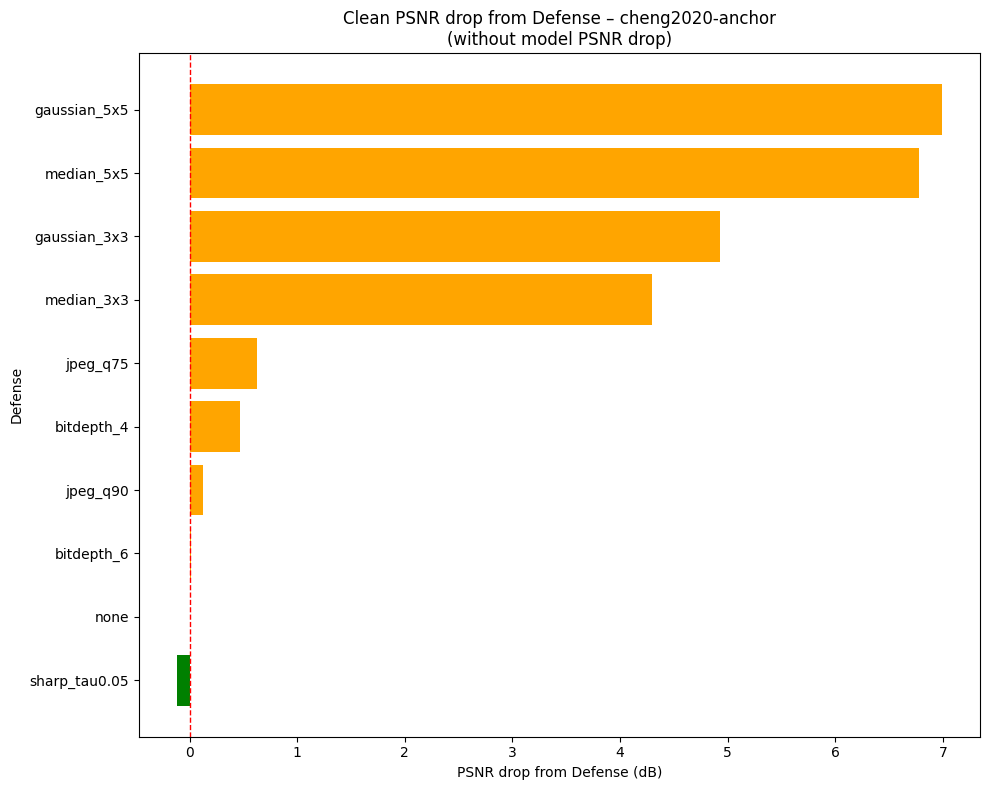

In [13]:
avg_clean = df.groupby('defense')['clean_psnr_drop'].mean()
# Получим значение для 'none'
none_val = avg_clean.get('none', None)
if none_val is not None:
    # Вычислим дополнительную потерю относительно none
    defense_penalty = avg_clean - none_val
    # Отсортируем
    defense_penalty = defense_penalty.sort_values()
    
    plt.figure(figsize=(10, 8))
    colors = ['green' if v < 0 else 'orange' for v in defense_penalty.values]
    plt.barh(defense_penalty.index, defense_penalty.values, color=colors)
    plt.xlabel('PSNR drop from Defense (dB)')
    plt.ylabel('Defense')
    plt.title(f'Clean PSNR drop from Defense – {MODEL_NAME}\n(without model PSNR drop)')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.savefig(f'defense_penalty_{MODEL_NAME}.png', dpi=150)
    plt.show()
else:
    print("Защита 'none' не найдена в данных.")